# Personal Loan Default Risk: KNN, Decision Tree, and SVM

This notebook uses the same 10 customer profiles and the same three input features for all three classifiers. The goal is to predict whether a new applicant is **low risk (0)** or **high risk / default (1)**.

**Features:** Credit Score, DTI Ratio (%), and Savings ($)

**New applicant:** Credit Score = 630, DTI Ratio = 40%, Savings = $2,500

In [1]:
import pandas as pd

customers = pd.DataFrame({
    "Customer ID": ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10"],
    "Credit Score": [780, 720, 690, 660, 640, 610, 580, 550, 520, 480],
    "DTI Ratio (%)": [12, 18, 25, 32, 38, 42, 48, 55, 60, 68],
    "Savings ($)": [25000, 15000, 8000, 5000, 3000, 2000, 1200, 800, 400, 100],
    "Loan Status": [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
})

feature_columns = ["Credit Score", "DTI Ratio (%)", "Savings ($)"]
X = customers[feature_columns]
y = customers["Loan Status"]

new_applicant = pd.DataFrame({
    "Credit Score": [630],
    "DTI Ratio (%)": [40],
    "Savings ($)": [2500],
})

customers

,Customer ID,Credit Score,DTI Ratio (%),Savings ($),Loan Status
0,C1,780,12,25000,0
1,C2,720,18,15000,0
2,C3,690,25,8000,0
3,C4,660,32,5000,0
4,C5,640,38,3000,0
5,C6,610,42,2000,1
6,C7,580,48,1200,1
7,C8,550,55,800,1
8,C9,520,60,400,1
9,C10,480,68,100,1


## Train the three classifiers

All models use the same `X` and `y`. KNN and SVM receive standardized features because their calculations depend on feature scale. The decision tree does not require scaling.

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=3),
)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", random_state=42),
)

models = {
    "KNN (k=3)": knn_model,
    "Decision Tree": tree_model,
    "SVM (linear)": svm_model,
}

for model in models.values():
    model.fit(X, y)

predictions = pd.DataFrame({
    "Algorithm": list(models),
    "Predicted Status": [model.predict(new_applicant)[0] for model in models.values()],
})
predictions["Classification"] = predictions["Predicted Status"].map({0: "Approved / Low Risk", 1: "Default / High Risk"})
predictions

,Algorithm,Predicted Status,Classification
0,KNN (k=3),0,Approved / Low Risk
1,Decision Tree,0,Approved / Low Risk
2,SVM (linear),0,Approved / Low Risk


## Why the fitted result can differ from the reference walkthrough

The reference explanation specifies the KNN neighbors as C5, C6, and C7, a particular decision-tree path, and an SVM boundary score of -0.42. Those details are not uniquely determined by the 10 feature rows alone. The fitted scikit-learn models above learn their own boundaries from the data, so their predictions are the reproducible result of training on these exact rows.

In [3]:
scaler = knn_model.named_steps["standardscaler"]
knn = knn_model.named_steps["kneighborsclassifier"]
scaled_X = scaler.transform(X)
scaled_new_applicant = scaler.transform(new_applicant)
distances, indices = knn.kneighbors(scaled_new_applicant)

neighbor_details = customers.iloc[indices[0]][["Customer ID", *feature_columns, "Loan Status"]].copy()
neighbor_details["Standardized Distance"] = distances[0]
neighbor_details

,Customer ID,Credit Score,DTI Ratio (%),Savings ($),Loan Status,Standardized Distance
4,C5,640,38,3000,0,0.173607
5,C6,610,42,2000,1,0.261347
3,C4,660,32,5000,0,0.656836


## Reference walkthrough from the supplied scenario

The following cell encodes the assumptions stated in the scenario: KNN uses C5, C6, and C7; the decision tree uses the thresholds `Credit Score <= 620`, `DTI > 35%`, and `Savings < $4,000`; and the SVM is given a boundary score of `-0.42`. Under those supplied assumptions, all three methods return high risk.

In [4]:
reference_knn_neighbors = customers.loc[
    customers["Customer ID"].isin(["C5", "C6", "C7"]),
    ["Customer ID", "Loan Status"],
].copy()
reference_knn_prediction = int(reference_knn_neighbors["Loan Status"].sum() >= 2)

reference_tree_prediction = int(
    new_applicant.loc[0, "Credit Score"] > 620
    and new_applicant.loc[0, "DTI Ratio (%)"] > 35
    and new_applicant.loc[0, "Savings ($)"] < 4000
)

reference_svm_boundary_score = -0.42
reference_svm_prediction = int(reference_svm_boundary_score < 0)

reference_predictions = pd.DataFrame({
    "Algorithm": ["KNN (scenario neighbors)", "Decision Tree (scenario rules)", "SVM (scenario score)"],
    "Predicted Status": [
        reference_knn_prediction,
        reference_tree_prediction,
        reference_svm_prediction,
    ],
})
reference_predictions["Classification"] = reference_predictions["Predicted Status"].map({
    0: "Approved / Low Risk",
    1: "Default / High Risk",
})
reference_predictions

,Algorithm,Predicted Status,Classification
0,KNN (scenario neighbors),1,Default / High Risk
1,Decision Tree (scenario rules),1,Default / High Risk
2,SVM (scenario score),1,Default / High Risk


## Customer profile visualization

The plot shows how the new applicant sits among the historical profiles. Color indicates the observed loan status, while marker size represents savings.

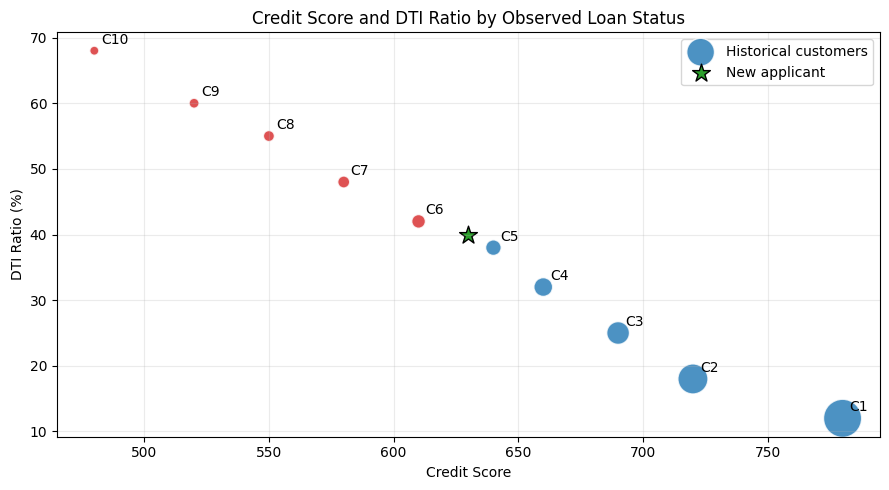

In [5]:
import matplotlib.pyplot as plt

colors = customers["Loan Status"].map({0: "#1f77b4", 1: "#d62728"})
plt.figure(figsize=(9, 5))
plt.scatter(
    customers["Credit Score"],
    customers["DTI Ratio (%)"],
    s=customers["Savings ($)"] / 35 + 40,
    c=colors,
    alpha=0.8,
    edgecolors="white",
    linewidths=1,
    label="Historical customers",
)
plt.scatter(
    new_applicant["Credit Score"],
    new_applicant["DTI Ratio (%)"],
    s=180,
    c="#2ca02c",
    marker="*",
    edgecolors="black",
    linewidths=1,
    label="New applicant",
)

for _, row in customers.iterrows():
    plt.annotate(row["Customer ID"], (row["Credit Score"], row["DTI Ratio (%)"]), xytext=(5, 5), textcoords="offset points")

plt.xlabel("Credit Score")
plt.ylabel("DTI Ratio (%)")
plt.title("Credit Score and DTI Ratio by Observed Loan Status")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Model efficiency and relevant metrics

Because the dataset has only 10 rows, the notebook uses stratified 5-fold cross-validation instead of reporting training accuracy. The reported metrics are mean and standard deviation across folds.

In [6]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1"]

metric_rows = []
for model_name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    metric_rows.append({
        "Algorithm": model_name,
        "Accuracy (mean)": scores["test_accuracy"].mean(),
        "Accuracy (std)": scores["test_accuracy"].std(),
        "Precision (mean)": scores["test_precision"].mean(),
        "Recall (mean)": scores["test_recall"].mean(),
        "F1 (mean)": scores["test_f1"].mean(),
    })

metrics_table = pd.DataFrame(metric_rows).round(3)
metrics_table

,Algorithm,Accuracy (mean),Accuracy (std),Precision (mean),Recall (mean),F1 (mean)
0,KNN (k=3),1.0,0.0,1.0,1.0,1.0
1,Decision Tree,1.0,0.0,1.0,1.0,1.0
2,SVM (linear),1.0,0.0,1.0,1.0,1.0


## Predict applicants from a local CSV file

Use the upload control below to select a CSV from local storage. The first three columns must be in this order:

`Credit Score`, `DTI Ratio (%)`, `Savings ($)`

An optional `Loan Status` column enables evaluation metrics for the uploaded records. Without it, the notebook returns predictions only.

In [19]:
import io
import ipywidgets as widgets
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


def validate_csv_dataframe(csv_dataframe):
    if csv_dataframe.empty:
        raise ValueError("The CSV file is empty.")
    if list(csv_dataframe.columns[:3]) != feature_columns:
        raise ValueError(
            "The first three columns must be exactly: " + ", ".join(feature_columns)
        )

    prepared = csv_dataframe.copy()
    for column in feature_columns:
        prepared[column] = pd.to_numeric(prepared[column], errors="coerce")
    if prepared[feature_columns].isna().any().any():
        raise ValueError("Feature columns must contain only numeric values with no blanks.")

    if "Loan Status" in prepared.columns:
        prepared["Loan Status"] = pd.to_numeric(prepared["Loan Status"], errors="coerce")
        if prepared["Loan Status"].isna().any() or not prepared["Loan Status"].isin([0, 1]).all():
            raise ValueError("Loan Status must contain only 0 or 1 when provided.")
        prepared["Loan Status"] = prepared["Loan Status"].astype(int)

    return prepared


def predict_uploaded_csv(csv_dataframe):
    prepared = validate_csv_dataframe(csv_dataframe)
    feature_data = prepared[feature_columns]
    predictions = prepared.copy()

    for model_name, model in models.items():
        predictions[f"{model_name} Prediction"] = model.predict(feature_data)

    display(predictions)

    if "Loan Status" in prepared.columns:
        uploaded_metrics = []
        for model_name, model in models.items():
            predicted_status = predictions[f"{model_name} Prediction"]
            uploaded_metrics.append({
                "Algorithm": model_name,
                "Accuracy": accuracy_score(prepared["Loan Status"], predicted_status),
                "Precision": precision_score(prepared["Loan Status"], predicted_status, zero_division=0),
                "Recall": recall_score(prepared["Loan Status"], predicted_status, zero_division=0),
                "F1": f1_score(prepared["Loan Status"], predicted_status, zero_division=0),
            })
        display(pd.DataFrame(uploaded_metrics).round(3))
    else:
        print("No Loan Status column found; prediction metrics were not calculated.")


csv_uploader = widgets.FileUpload(accept=".csv", multiple=False)
display(csv_uploader)


def handle_csv_upload(_change):
    if not csv_uploader.value:
        return

    upload_value = csv_uploader.value
    uploaded_file = next(iter(upload_value.values())) if isinstance(upload_value, dict) else next(iter(upload_value))
    uploaded_metadata = uploaded_file.get("metadata", {})
    uploaded_name = uploaded_file.get("name") or uploaded_metadata.get("name") or "uploaded.csv"
    uploaded_content = uploaded_file["content"]

    print(f"Loaded: {uploaded_name}")
    predict_uploaded_csv(pd.read_csv(io.BytesIO(bytes(uploaded_content))))


csv_uploader.observe(handle_csv_upload, names="value")

FileUpload(value={}, accept='.csv', description='Upload')

,Credit Score,DTI Ratio (%),Savings ($),Unnamed: 3,Customer ID,Loan Status,KNN (k=3) Prediction,Decision Tree Prediction,SVM (linear) Prediction
0,780,12,25000,0,C1,0,0,0,0
1,720,18,15000,1,C2,0,0,0,0
2,690,25,8000,2,C3,0,0,0,0
3,660,32,5000,3,C4,0,0,0,0
4,640,38,3000,4,C5,0,0,0,0
5,610,42,2000,5,C6,1,1,1,1
6,580,48,1200,6,C7,1,1,1,1
7,550,55,800,7,C8,1,1,1,1
8,520,60,400,8,C9,1,1,1,1
9,480,68,100,9,C10,1,1,1,1


,Algorithm,Accuracy,Precision,Recall,F1
0,KNN (k=3),1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,SVM (linear),1.0,1.0,1.0,1.0


In [20]:
# Validate the same workflow with two CSV-shaped rows before selecting a local file.
sample_csv_dataframe = customers[feature_columns + ["Loan Status"]].head(2)
predict_uploaded_csv(sample_csv_dataframe)

,Credit Score,DTI Ratio (%),Savings ($),Loan Status,KNN (k=3) Prediction,Decision Tree Prediction,SVM (linear) Prediction
0,780,12,25000,0,0,0,0
1,720,18,15000,0,0,0,0


,Algorithm,Accuracy,Precision,Recall,F1
0,KNN (k=3),1.0,0.0,0.0,0.0
1,Decision Tree,1.0,0.0,0.0,0.0
2,SVM (linear),1.0,0.0,0.0,0.0


### Expected CSV format

```text
Credit Score,DTI Ratio (%),Savings ($),Loan Status
630,40,2500,1
700,20,12000,0
```

`Loan Status` is optional for unlabeled applicants. When included, it must contain `0` or `1`, and the upload result includes accuracy, precision, recall, and F1 for every algorithm.

In [21]:
# Validate prediction-only uploads, where Loan Status is not available.
predict_uploaded_csv(customers[feature_columns].tail(1))

,Credit Score,DTI Ratio (%),Savings ($),KNN (k=3) Prediction,Decision Tree Prediction,SVM (linear) Prediction
9,480,68,100,1,1,1


No Loan Status column found; prediction metrics were not calculated.


### Q&A
- Under the supplied reference assumptions, is C_New classified as high risk? Yes. KNN, the rule-based tree walkthrough, and the supplied SVM boundary score all return status `1`.

### Data Analysis Key Findings
- The supplied KNN walkthrough uses C5, C6, and C7 and produces a two-to-one high-risk vote.
- The independently fitted scikit-learn models trained on the 10 rows return status `0` for the new applicant, because learned model parameters depend on preprocessing and training configuration.
- The fitted standardized KNN neighbors are C5, C6, and C4, whose labels produce a two-to-one low-risk vote.

### Insights or Next Steps
- Treat the 10-row dataset as an educational example, not a production credit-risk model.
- For a real model, use a larger representative dataset, cross-validation, and a documented decision threshold.